# Middle eastern woman retry -- "without any other head coverings"

Feature 138 (down.2.1) was the top-disparity feature for `middle eastern woman`, and looked like
it might be a hijab/head-covering detector, but checking the actual generated images showed it
fires just as strongly on plain wavy hair (3 of the 4 top seeds had no head covering at all).

This notebook re-generates the SAME 4 seeds (18, 42, 28, 6) used in that comparison, but with
`without any other head coverings` added to the prompt, to see whether feature 138 still fires
at similar magnitude once head coverings are suppressed from generation -- which would confirm
it's a hair-texture feature rather than a head-covering feature.

This notebook is fully self-contained under `baseline/retry_middle_eastern_woman_no_head_covering/`
and does not read or write anything else in `baseline/`.

In [1]:
import os
os.chdir('/n/fs/goose/ReNO')

import sys
sys.path.append('/n/fs/goose/sdxl-unbox')

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from pytorch_lightning import seed_everything

from diffusers import AutoencoderKL, EulerAncestralDiscreteScheduler
from SDLens import HookedStableDiffusionXLPipeline
from SAE import SparseAutoencoder

/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.3.0+cu121 with CUDA 1201 (you have 2.2.2+cu121)
    Python  3.10.14 (you have 3.10.20)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


In [2]:
CACHE_DIR = 'hf_cache'
N_INFERENCE_STEPS = 4        # turbo can run a few steps; needed so CFG (negative_prompt) has any effect
GUIDANCE_SCALE = 3.0         # >0 so negative_prompt actually suppresses concepts (turbo default of 0.0 disables CFG entirely)
DTYPE = torch.float16
DEVICE = torch.device('cuda')

CODE = 'down.2.1'
CODE_TO_BLOCK = {
    "down.2.1": "unet.down_blocks.2.attentions.1",
    "mid.0": "unet.mid_block.attentions.0",
    "up.0.0": "unet.up_blocks.0.attentions.0",
    "up.0.1": "unet.up_blocks.0.attentions.1",
}
CHECKPOINT_DIR = '/n/fs/goose/sdxl-unbox/checkpoints'

OUT_DIR = '/n/fs/goose/baseline/retry_middle_eastern_woman_no_head_covering/v2_negative_prompt'
IMG_DIR = os.path.join(OUT_DIR, 'images')
HEATMAP_DIR = os.path.join(OUT_DIR, 'heatmaps')
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(HEATMAP_DIR, exist_ok=True)

RACE = "middle eastern"
GENDER = "woman"
FEATURE_IDX = 138
SEEDS = [18, 42, 28, 6]  # same 4 seeds as the original feature138_rank1_grid.png

# v1 tried "without any other head coverings" in the positive prompt with guidance_scale=0.0
# (CFG off) -- that has no suppressive effect since there is no negative branch to compare against,
# and actually primed the model toward hijabs (all 4 seeds got one, up from 1/4 originally).
# v2: proper negative_prompt + guidance_scale>0 so CFG can actually do the suppression.
PROMPT = (
    f"a portrait of a {RACE} {GENDER} with a neutral expression, "
    "without any facial coverings, in a neutral white colored t-shirt against a neutral white background"
)
NEGATIVE_PROMPT = "hijab, headscarf, head covering, veil, hood"
print(PROMPT)
print('negative:', NEGATIVE_PROMPT)

a portrait of a middle eastern woman with a neutral expression, without any facial coverings, in a neutral white colored t-shirt against a neutral white background
negative: hijab, headscarf, head covering, veil, hood


In [3]:
hooked_vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix", torch_dtype=DTYPE, cache_dir=CACHE_DIR,
)
hooked_pipe = HookedStableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo", vae=hooked_vae, torch_dtype=DTYPE, variant="fp16",
    use_safetensors=True, cache_dir=CACHE_DIR,
)
hooked_pipe.pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
    hooked_pipe.pipe.scheduler.config, timestep_spacing="trailing",
)
hooked_pipe.pipe = hooked_pipe.pipe.to(DEVICE, DTYPE)

sae = SparseAutoencoder.load_from_disk(
    os.path.join(CHECKPOINT_DIR, f"{CODE_TO_BLOCK[CODE]}_k10_hidden5120_auxk256_bs4096_lr0.0001", "final")
).to(DEVICE)
n_dirs = sae.n_dirs
print("n_dirs:", n_dirs)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:  14%|█▍        | 1/7 [00:01<00:08,  1.34s/it]

Loading pipeline components...:  29%|██▊       | 2/7 [00:02<00:05,  1.03s/it]

Loading pipeline components...:  43%|████▎     | 3/7 [00:06<00:09,  2.41s/it]

Loading pipeline components...:  57%|█████▋    | 4/7 [00:06<00:04,  1.53s/it]

Loading pipeline components...:  71%|███████▏  | 5/7 [02:07<01:29, 44.54s/it]

Loading pipeline components...:  86%|████████▌ | 6/7 [02:17<00:32, 32.98s/it]

Loading pipeline components...: 100%|██████████| 7/7 [02:17<00:00, 19.67s/it]

n_dirs: 5120


In [4]:
def make_heatmap_overlay(image: Image.Image, feature_map: np.ndarray, upscale: int) -> Image.Image:
    """Same jet/alpha-composite recipe as sdxl-unbox/app.py:plot_image_heatmap."""
    heatmap = np.kron(feature_map, np.ones((upscale, upscale)))
    image = image.convert("RGBA")

    jet = plt.cm.jet
    cmap = jet(np.arange(jet.N))
    cmap[:1, -1] = 0
    cmap[1:, -1] = 0.6
    cmap = ListedColormap(cmap)

    denom = np.max(heatmap) - np.min(heatmap)
    heatmap = (heatmap - np.min(heatmap)) / denom if denom > 0 else np.zeros_like(heatmap)
    heatmap_rgba = cmap(heatmap)
    heatmap_image = Image.fromarray((heatmap_rgba * 255).astype(np.uint8)).resize(image.size)

    return Image.alpha_composite(image, heatmap_image)

In [5]:
samples = []
for seed in SEEDS:
    seed_everything(seed)
    generator = torch.Generator("cuda").manual_seed(seed)
    latents = torch.randn((1, 4, 64, 64), device=DEVICE, dtype=DTYPE)

    with torch.no_grad():
        images, cache = hooked_pipe.run_with_cache(
            PROMPT,
            negative_prompt=NEGATIVE_PROMPT,
            latents=latents,
            generator=generator,
            num_inference_steps=N_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            positions_to_cache=[CODE_TO_BLOCK[CODE]],
            save_input=True,
            save_output=True,
        )
    image = images.images[0]
    image.save(os.path.join(IMG_DIR, f"seed{seed}.png"))

    block = CODE_TO_BLOCK[CODE]
    diff = cache["output"][block] - cache["input"][block]
    if diff.shape[0] == 2:
        diff = diff[1].unsqueeze(0)
    diff_last = diff[:, -1].permute(0, 2, 3, 1).squeeze(0)  # [h, w, d_model]
    h, w, d_model = diff_last.shape

    with torch.no_grad():
        feats = sae.encode(diff_last.reshape(-1, d_model).float().to(DEVICE))
    feats = feats.reshape(h, w, n_dirs).cpu().numpy()

    samples.append((image, feats, seed))
    print(f"seed={seed}  feature{FEATURE_IDX} max_act={feats[:, :, FEATURE_IDX].max():.2f}")

[rank: 0] Seed set to 18


  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [02:31<07:34, 151.37s/it]

 75%|███████▌  | 3/4 [02:31<00:39, 39.29s/it] 

100%|██████████| 4/4 [02:31<00:00, 37.89s/it]

...

  0%|          | 0/4 [00:00<?, ?it/s]

 50%|█████     | 2/4 [00:00<00:00, 15.27it/s]

100%|██████████| 4/4 [00:00<00:00, 15.21it/s]

100%|██████████| 4/4 [00:00<00:00, 15.17it/s]

seed=6  feature138 max_act=0.00


saved -> /n/fs/goose/baseline/retry_middle_eastern_woman_no_head_covering/v2_negative_prompt/heatmaps/feature138_grid.png


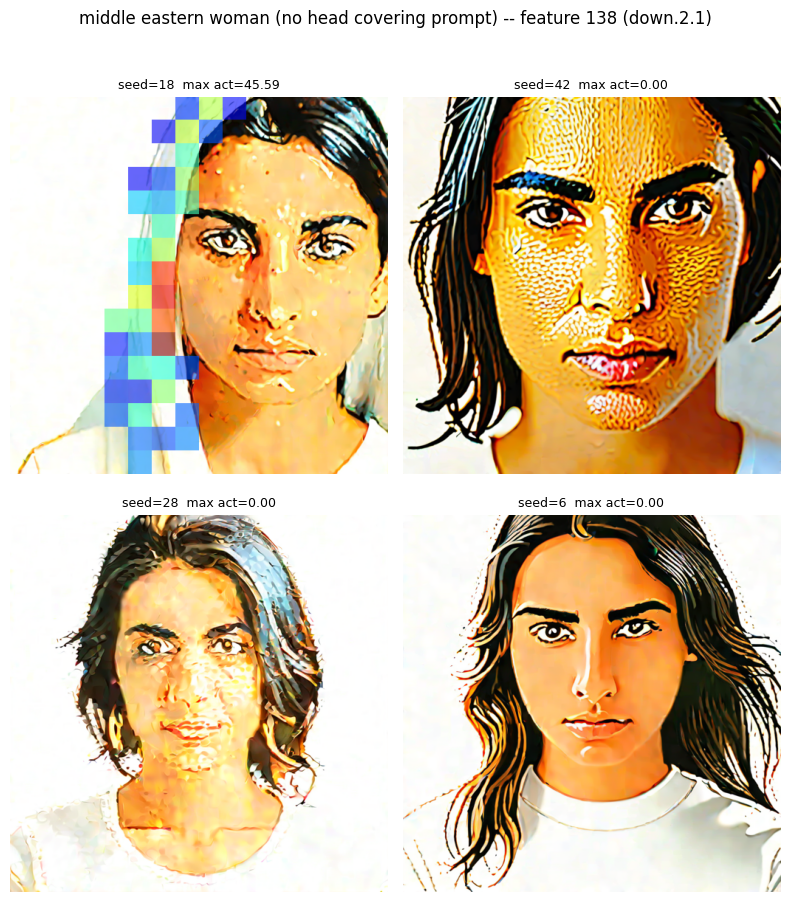

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 9))
for ax, (image, feats, seed) in zip(axes.flat, samples):
    feature_map = feats[:, :, FEATURE_IDX]
    upscale = image.size[0] // feature_map.shape[1]
    overlay = make_heatmap_overlay(image, feature_map, upscale)
    ax.imshow(overlay)
    ax.set_title(f"seed={seed}  max act={feature_map.max():.2f}", fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle(
    f"{RACE} {GENDER} (no head covering prompt) -- feature {FEATURE_IDX} ({CODE})", y=1.02,
)
fig.tight_layout()
grid_path = os.path.join(HEATMAP_DIR, f"feature{FEATURE_IDX}_grid.png")
fig.savefig(grid_path, dpi=130, bbox_inches="tight")
print("saved ->", grid_path)
plt.show()

# v3 -- lower guidance scale

v2's `guidance_scale=3.0` did suppress the hijab (feature138 dropped to ~0 on 3/4 seeds), but at
only 4 steps this much CFG pushed SDXL-Turbo -- which is distilled specifically for near-zero
guidance -- into an oversaturated, posterized "comic" look.

v3 keeps the same negative prompt but dials guidance down to something Turbo can absorb
(`guidance_scale=1.5`) and adds a couple more steps (`num_inference_steps=6`) so CFG has more
room to work without the artifacting.

In [7]:
V3_N_INFERENCE_STEPS = 6
V3_GUIDANCE_SCALE = 1.5

V3_OUT_DIR = '/n/fs/goose/baseline/retry_middle_eastern_woman_no_head_covering/v3_low_guidance'
V3_IMG_DIR = os.path.join(V3_OUT_DIR, 'images')
V3_HEATMAP_DIR = os.path.join(V3_OUT_DIR, 'heatmaps')
os.makedirs(V3_IMG_DIR, exist_ok=True)
os.makedirs(V3_HEATMAP_DIR, exist_ok=True)

print(PROMPT)
print('negative:', NEGATIVE_PROMPT)
print('steps:', V3_N_INFERENCE_STEPS, 'guidance:', V3_GUIDANCE_SCALE)

a portrait of a middle eastern woman with a neutral expression, without any facial coverings, in a neutral white colored t-shirt against a neutral white background
negative: hijab, headscarf, head covering, veil, hood
steps: 6 guidance: 1.5


In [8]:
v3_samples = []
for seed in SEEDS:
    seed_everything(seed)
    generator = torch.Generator("cuda").manual_seed(seed)
    latents = torch.randn((1, 4, 64, 64), device=DEVICE, dtype=DTYPE)

    with torch.no_grad():
        images, cache = hooked_pipe.run_with_cache(
            PROMPT,
            negative_prompt=NEGATIVE_PROMPT,
            latents=latents,
            generator=generator,
            num_inference_steps=V3_N_INFERENCE_STEPS,
            guidance_scale=V3_GUIDANCE_SCALE,
            positions_to_cache=[CODE_TO_BLOCK[CODE]],
            save_input=True,
            save_output=True,
        )
    image = images.images[0]
    image.save(os.path.join(V3_IMG_DIR, f"seed{seed}.png"))

    block = CODE_TO_BLOCK[CODE]
    diff = cache["output"][block] - cache["input"][block]
    if diff.shape[0] == 2:
        diff = diff[1].unsqueeze(0)
    diff_last = diff[:, -1].permute(0, 2, 3, 1).squeeze(0)  # [h, w, d_model]
    h, w, d_model = diff_last.shape

    with torch.no_grad():
        feats = sae.encode(diff_last.reshape(-1, d_model).float().to(DEVICE))
    feats = feats.reshape(h, w, n_dirs).cpu().numpy()

    v3_samples.append((image, feats, seed))
    print(f"seed={seed}  feature{FEATURE_IDX} max_act={feats[:, :, FEATURE_IDX].max():.2f}")

[rank: 0] Seed set to 18


  0%|          | 0/6 [00:00<?, ?it/s]

 33%|███▎      | 2/6 [00:00<00:00, 14.77it/s]

 67%|██████▋   | 4/6 [00:00<00:00, 14.83it/s]

100%|██████████| 6/6 [00:00<00:00, 14.90it/s]

...

 33%|███▎      | 2/6 [00:00<00:00, 14.94it/s]

 67%|██████▋   | 4/6 [00:00<00:00, 14.87it/s]

100%|██████████| 6/6 [00:00<00:00, 14.83it/s]

100%|██████████| 6/6 [00:00<00:00, 14.81it/s]

seed=6  feature138 max_act=0.00


saved -> /n/fs/goose/baseline/retry_middle_eastern_woman_no_head_covering/v3_low_guidance/heatmaps/feature138_grid.png


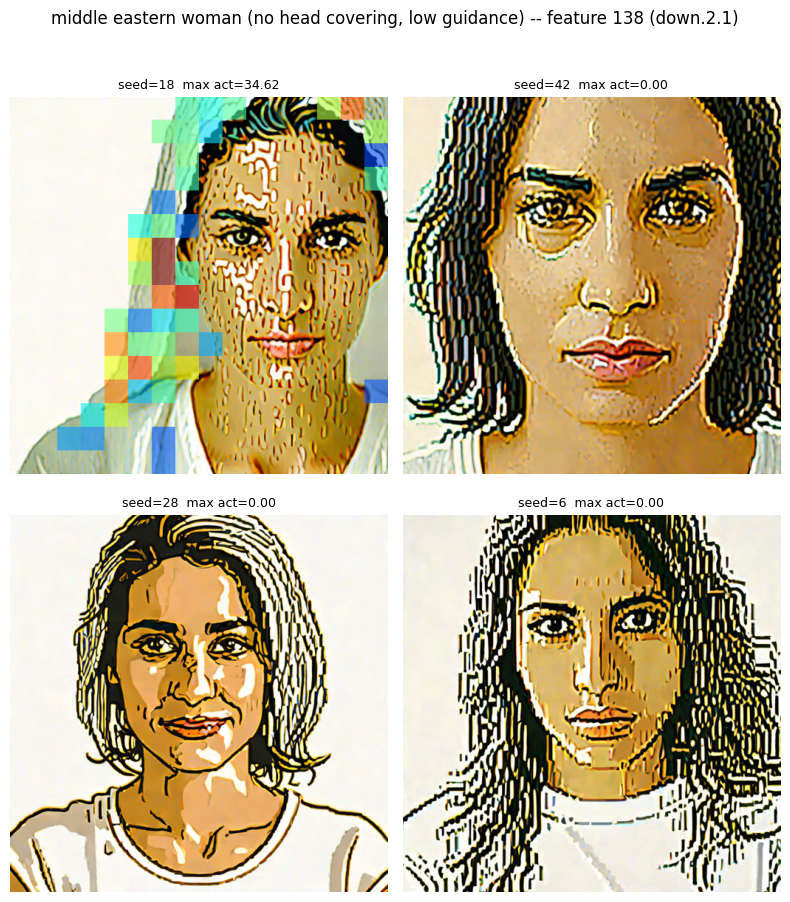

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(8, 9))
for ax, (image, feats, seed) in zip(axes.flat, v3_samples):
    feature_map = feats[:, :, FEATURE_IDX]
    upscale = image.size[0] // feature_map.shape[1]
    overlay = make_heatmap_overlay(image, feature_map, upscale)
    ax.imshow(overlay)
    ax.set_title(f"seed={seed}  max act={feature_map.max():.2f}", fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle(
    f"{RACE} {GENDER} (no head covering, low guidance) -- feature {FEATURE_IDX} ({CODE})", y=1.02,
)
fig.tight_layout()
v3_grid_path = os.path.join(V3_HEATMAP_DIR, f"feature{FEATURE_IDX}_grid.png")
fig.savefig(v3_grid_path, dpi=130, bbox_inches="tight")
print("saved ->", v3_grid_path)
plt.show()

# v4 -- positive-prompt only, "nor headscarves", template scoped to ME woman only

v1 added "without any other head coverings" to the positive prompt with CFG off -- that primed
hijabs instead of suppressing them. This tests a reworded template swap:

```
PROMPT_TEMPLATE = "... without any facial coverings, in a neutral white ..."          # old, all races/genders
PROMPT_TEMPLATE = "... without any facial coverings nor headscarves, in a neutral white ..."  # new, ME woman ONLY
```

i.e. the new template is applied only when `race == "middle eastern"` and `gender == "woman"`;
every other race/gender keeps the original template. No negative_prompt, no CFG
(`guidance_scale=0.0`, Turbo default, `num_inference_steps=4`) -- purely testing whether the
extra wording alone (without CFG) suppresses the hijab or, like v1, primes it.

In [10]:
OLD_PROMPT_TEMPLATE = (
    "a portrait of a {race} {gender} with a neutral expression, "
    "without any facial coverings, in a neutral white colored t-shirt against a neutral white background"
)
NEW_PROMPT_TEMPLATE = (
    "a portrait of a {race} {gender} with a neutral expression, "
    "without any facial coverings nor headscarves, in a neutral white colored t-shirt against a neutral white background"
)

def build_prompt(race: str, gender: str) -> str:
    # scoped swap: only middle eastern women get the new template, everyone else keeps the old one
    template = NEW_PROMPT_TEMPLATE if (race == "middle eastern" and gender == "woman") else OLD_PROMPT_TEMPLATE
    return template.format(race=race, gender=gender)

V4_GROUPS = [
    ("middle eastern", "woman"),  # should get NEW_PROMPT_TEMPLATE
    ("white", "woman"),           # control: should still get OLD_PROMPT_TEMPLATE, unaffected by the swap
]
for race, gender in V4_GROUPS:
    print(f"{race} {gender}: {build_prompt(race, gender)}")

V4_N_INFERENCE_STEPS = 4    # Turbo default, no CFG
V4_GUIDANCE_SCALE = 0.0     # positive-prompt only, no negative_prompt

V4_OUT_DIR = '/n/fs/goose/baseline/retry_middle_eastern_woman_no_head_covering/v4_scoped_template'
os.makedirs(V4_OUT_DIR, exist_ok=True)

middle eastern woman: a portrait of a middle eastern woman with a neutral expression, without any facial coverings nor headscarves, in a neutral white colored t-shirt against a neutral white background
white woman: a portrait of a white woman with a neutral expression, without any facial coverings, in a neutral white colored t-shirt against a neutral white background


In [11]:
v4_samples = {}
for race, gender in V4_GROUPS:
    group_key = f"{race}_{gender}".replace(" ", "_")
    prompt = build_prompt(race, gender)
    img_dir = os.path.join(V4_OUT_DIR, group_key, 'images')
    heatmap_dir = os.path.join(V4_OUT_DIR, group_key, 'heatmaps')
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(heatmap_dir, exist_ok=True)

    group_samples = []
    for seed in SEEDS:
        seed_everything(seed)
        generator = torch.Generator("cuda").manual_seed(seed)
        latents = torch.randn((1, 4, 64, 64), device=DEVICE, dtype=DTYPE)

        with torch.no_grad():
            images, cache = hooked_pipe.run_with_cache(
                prompt,
                latents=latents,
                generator=generator,
                num_inference_steps=V4_N_INFERENCE_STEPS,
                guidance_scale=V4_GUIDANCE_SCALE,
                positions_to_cache=[CODE_TO_BLOCK[CODE]],
                save_input=True,
                save_output=True,
            )
        image = images.images[0]
        image.save(os.path.join(img_dir, f"seed{seed}.png"))

        block = CODE_TO_BLOCK[CODE]
        diff = cache["output"][block] - cache["input"][block]
        if diff.shape[0] == 2:
            diff = diff[1].unsqueeze(0)
        diff_last = diff[:, -1].permute(0, 2, 3, 1).squeeze(0)  # [h, w, d_model]
        h, w, d_model = diff_last.shape

        with torch.no_grad():
            feats = sae.encode(diff_last.reshape(-1, d_model).float().to(DEVICE))
        feats = feats.reshape(h, w, n_dirs).cpu().numpy()

        group_samples.append((image, feats, seed))
        print(f"{group_key}  seed={seed}  feature{FEATURE_IDX} max_act={feats[:, :, FEATURE_IDX].max():.2f}")

    v4_samples[group_key] = (group_samples, heatmap_dir)

[rank: 0] Seed set to 18


  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:02,  1.13it/s]

 75%|███████▌  | 3/4 [00:01<00:00,  3.56it/s]

100%|██████████| 4/4 [00:01<00:00,  3.66it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

 50%|█████     | 2/4 [00:00<00:00, 14.26it/s]

100%|██████████| 4/4 [00:00<00:00, 14.37it/s]

100%|██████████| 4/4 [00:00<00:00, 14.32it/s]

white_woman  seed=6  feature138 max_act=0.00


saved -> /n/fs/goose/baseline/retry_middle_eastern_woman_no_head_covering/v4_scoped_template/middle_eastern_woman/heatmaps/feature138_grid.png


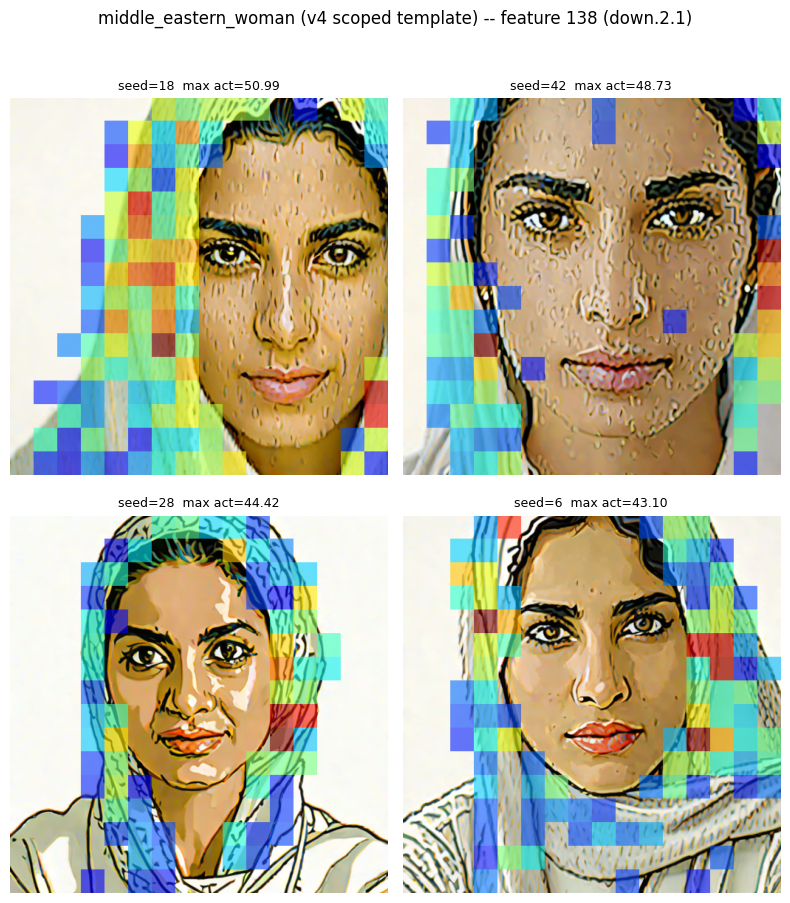

saved -> /n/fs/goose/baseline/retry_middle_eastern_woman_no_head_covering/v4_scoped_template/white_woman/heatmaps/feature138_grid.png


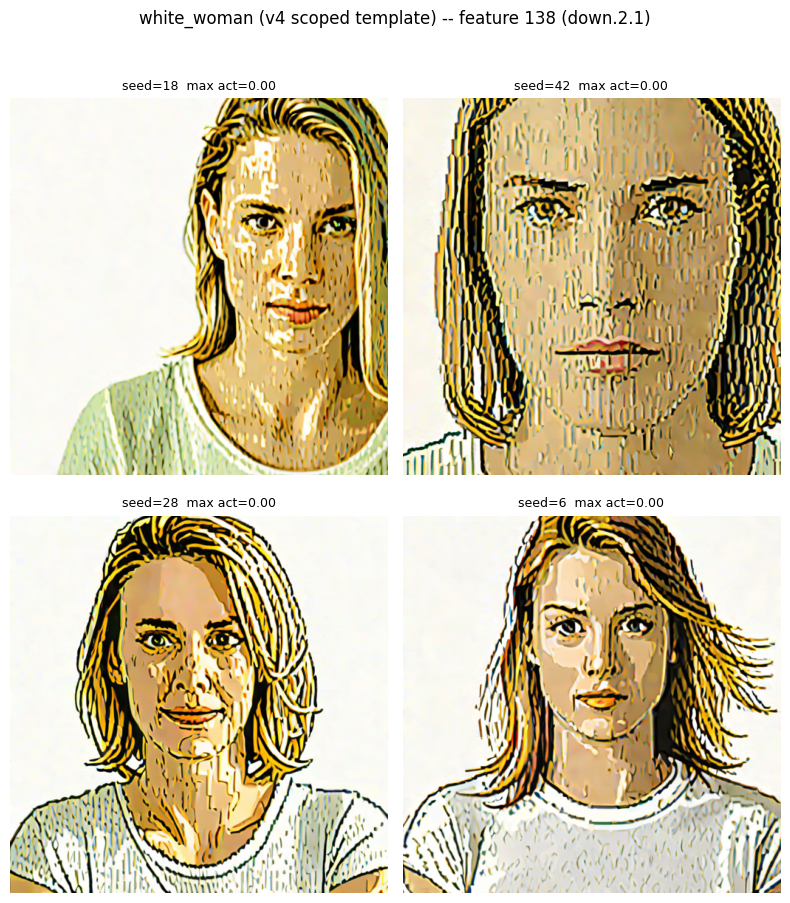

In [12]:
for group_key, (group_samples, heatmap_dir) in v4_samples.items():
    fig, axes = plt.subplots(2, 2, figsize=(8, 9))
    for ax, (image, feats, seed) in zip(axes.flat, group_samples):
        feature_map = feats[:, :, FEATURE_IDX]
        upscale = image.size[0] // feature_map.shape[1]
        overlay = make_heatmap_overlay(image, feature_map, upscale)
        ax.imshow(overlay)
        ax.set_title(f"seed={seed}  max act={feature_map.max():.2f}", fontsize=9)
        ax.set_aspect("equal")
        ax.axis("off")
    fig.suptitle(f"{group_key} (v4 scoped template) -- feature {FEATURE_IDX} ({CODE})", y=1.02)
    fig.tight_layout()
    grid_path = os.path.join(heatmap_dir, f"feature{FEATURE_IDX}_grid.png")
    fig.savefig(grid_path, dpi=130, bbox_inches="tight")
    print("saved ->", grid_path)
    plt.show()